In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.tree import plot_tree

In [6]:
df=pd.read_csv(r"C:\Users\INDIA\Data-Science-and-Machine-Learning-\ml\supervised_machine_learning\DecisionTree\DataSet\wine+quality\winequality-white.csv",sep=";")

In [7]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [9]:
print(df.shape)

(4898, 12)


In [10]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB
None


In [11]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [12]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

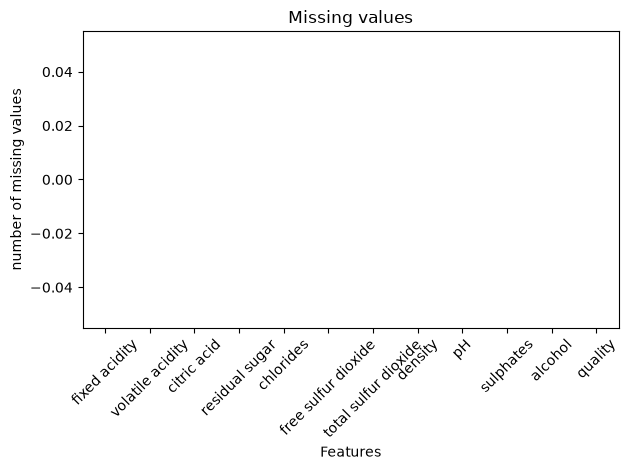

In [14]:
df.isnull().sum().plot(kind="bar")
plt.title("Missing values")
plt.xlabel("Features")
plt.ylabel("number of missing values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
print(df["quality"].value_counts().sort_index())

quality
3      20
4     163
5    1457
6    2198
7     880
8     175
9       5
Name: count, dtype: int64


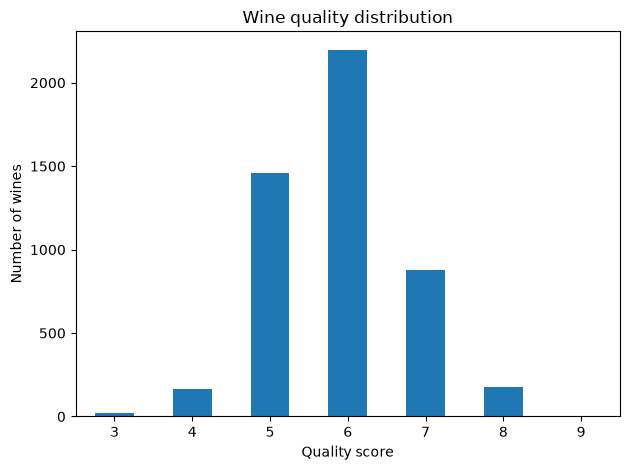

In [17]:
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.title("Wine quality distribution")
plt.xlabel("Quality score")
plt.ylabel("Number of wines")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

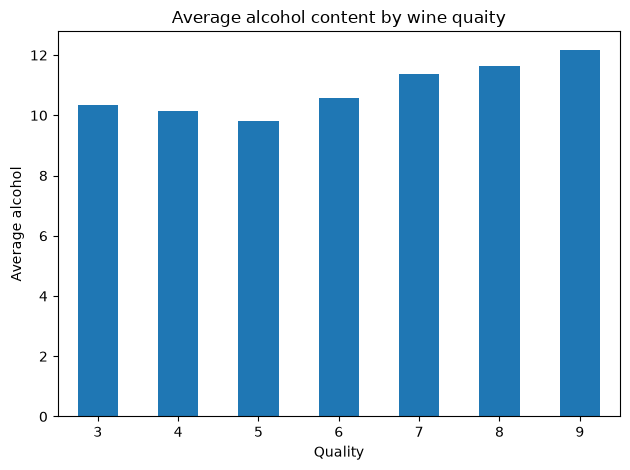

In [19]:
quality_alcohol = df.groupby(
    "quality"
)["alcohol"].mean()
quality_alcohol.plot(
    kind="bar"
)
plt.title("Average alcohol content by wine quaity")
plt.xlabel("Quality")
plt.ylabel("Average alcohol")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

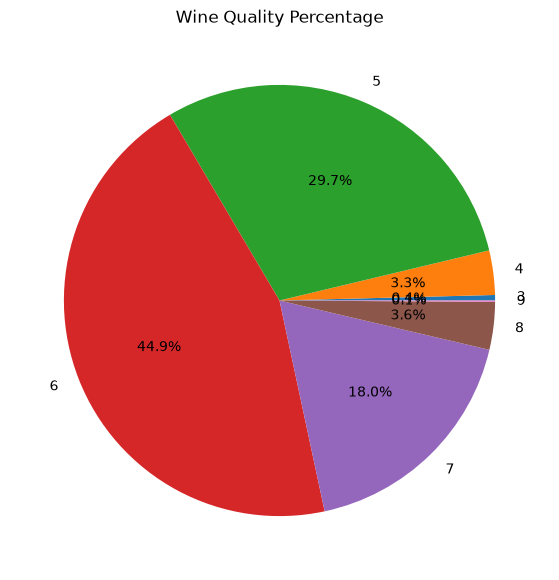

In [20]:
plt.figure(figsize=(7, 7))

df["quality"].value_counts().sort_index().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Wine Quality Percentage")
plt.ylabel("")

plt.show()

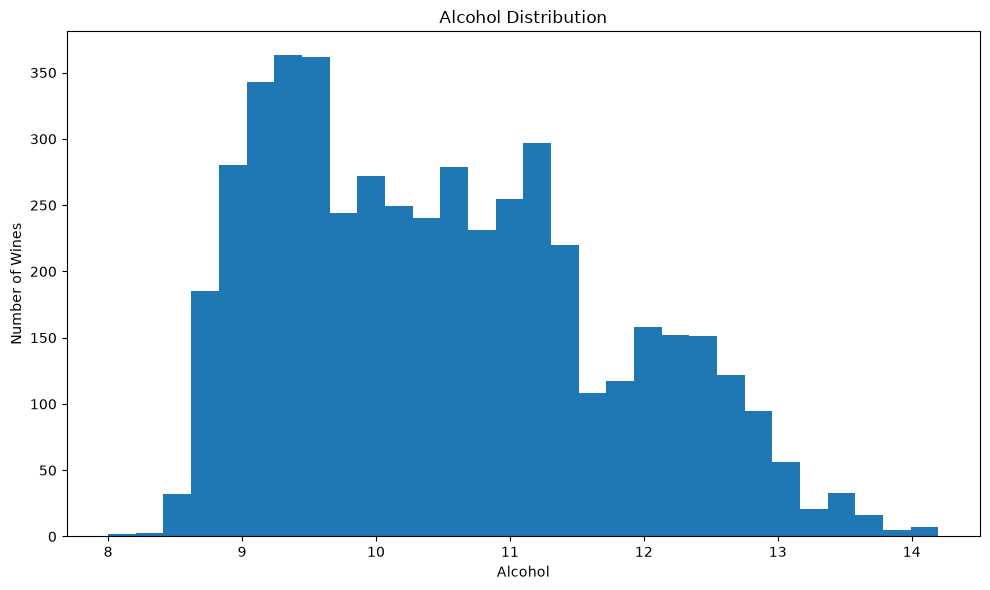

In [21]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["alcohol"],
    bins=30
)

plt.title("Alcohol Distribution")
plt.xlabel("Alcohol")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.show()

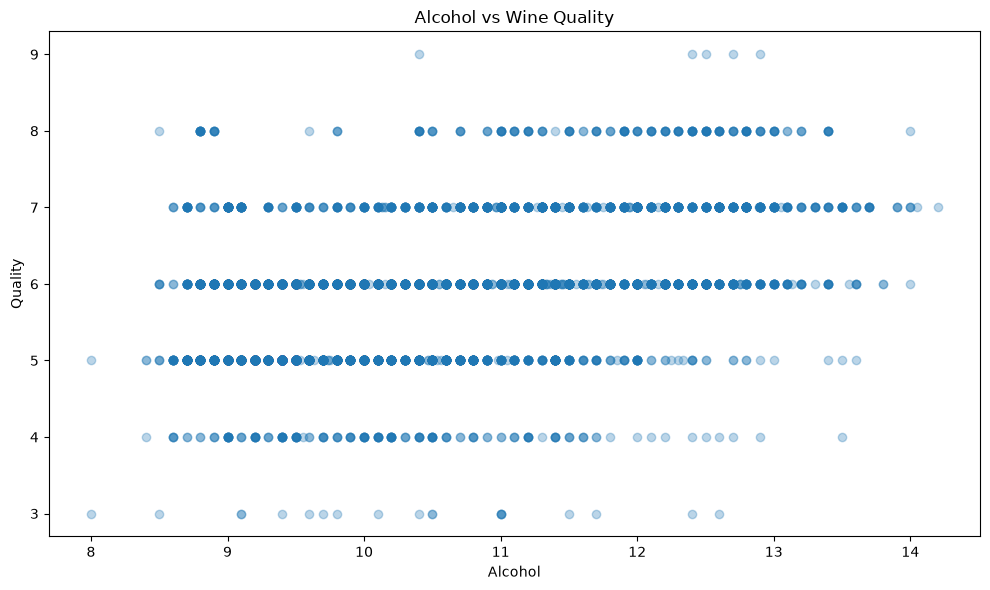

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["alcohol"],
    df["quality"],
    alpha=0.3
)

plt.title("Alcohol vs Wine Quality")
plt.xlabel("Alcohol")
plt.ylabel("Quality")

plt.tight_layout()
plt.show()

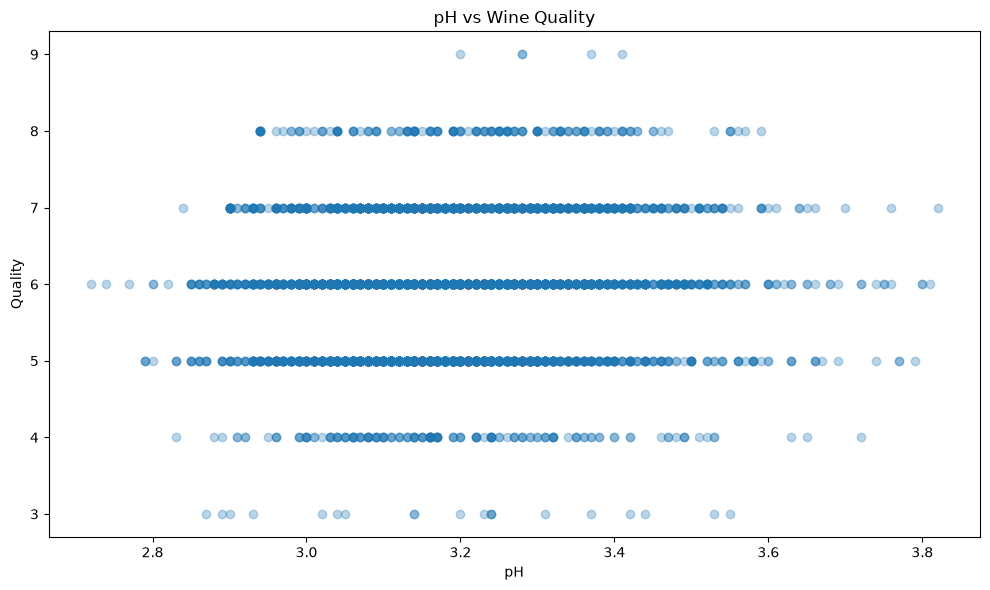

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["pH"],
    df["quality"],
    alpha=0.3
)

plt.title("pH vs Wine Quality")
plt.xlabel("pH")
plt.ylabel("Quality")

plt.tight_layout()
plt.show()

In [24]:
correlation = df.corr()

print(correlation)

                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.022697     0.289181   
volatile acidity          -0.022697          1.000000    -0.149472   
citric acid                0.289181         -0.149472     1.000000   
residual sugar             0.089021          0.064286     0.094212   
chlorides                  0.023086          0.070512     0.114364   
free sulfur dioxide       -0.049396         -0.097012     0.094077   
total sulfur dioxide       0.091070          0.089261     0.121131   
density                    0.265331          0.027114     0.149503   
pH                        -0.425858         -0.031915    -0.163748   
sulphates                 -0.017143         -0.035728     0.062331   
alcohol                   -0.120881          0.067718    -0.075729   
quality                   -0.113663         -0.194723    -0.009209   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity    

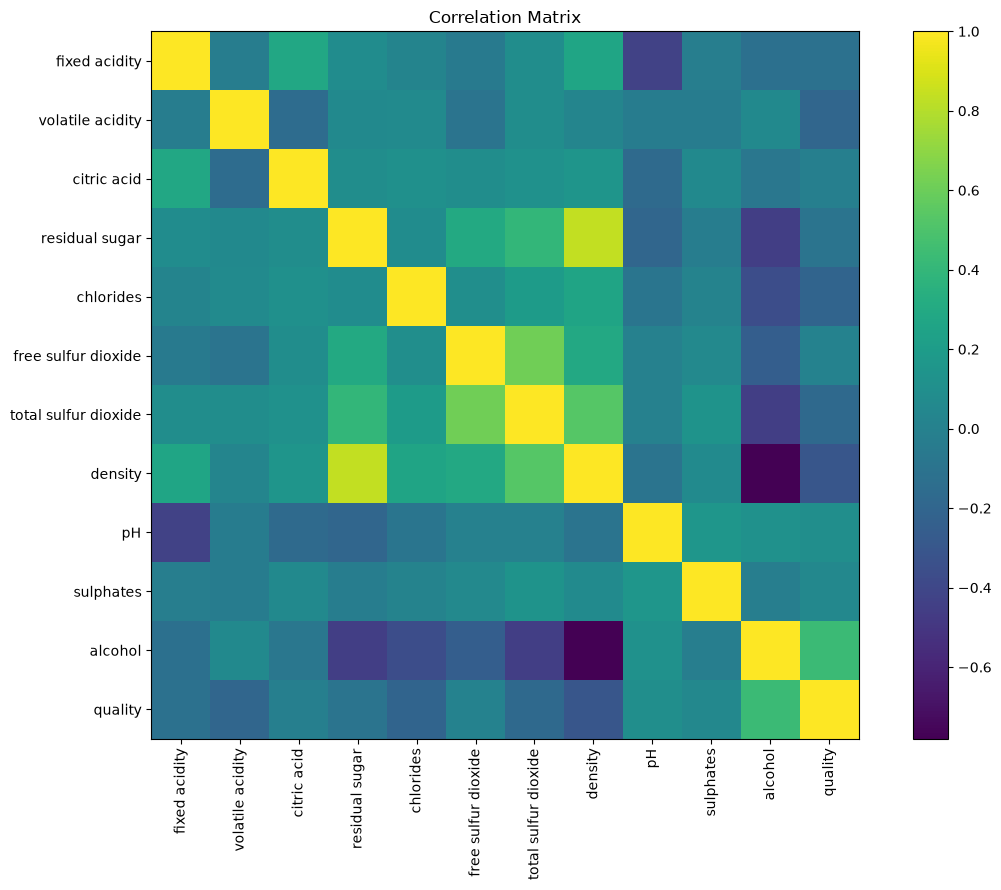

In [25]:
plt.figure(figsize=(12, 9))

plt.imshow(
    correlation,
    interpolation="nearest"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [27]:
x=df.drop("quality",axis=1)
y=df["quality"]

In [29]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print(x_train.shape)
print(x_test.shape)

(3918, 11)
(980, 11)


In [38]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(x_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [40]:
y_pred=model.predict(x_test)
print("Prediction")

Prediction


In [41]:
print(y_pred[:20])

[6 8 7 6 6 7 5 5 6 5 7 5 6 5 8 5 6 6 6 5]


In [42]:
accuracy = accuracy_score(y_test,y_pred)
print(accuracy)

0.5163265306122449


In [43]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         5
           4       0.33      0.08      0.13        25
           5       0.56      0.58      0.57       291
           6       0.52      0.62      0.56       432
           7       0.47      0.33      0.39       192
           8       0.10      0.03      0.04        35

    accuracy                           0.52       980
   macro avg       0.33      0.27      0.28       980
weighted avg       0.50      0.52      0.50       980



C:\Users\INDIA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\INDIA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\INDIA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

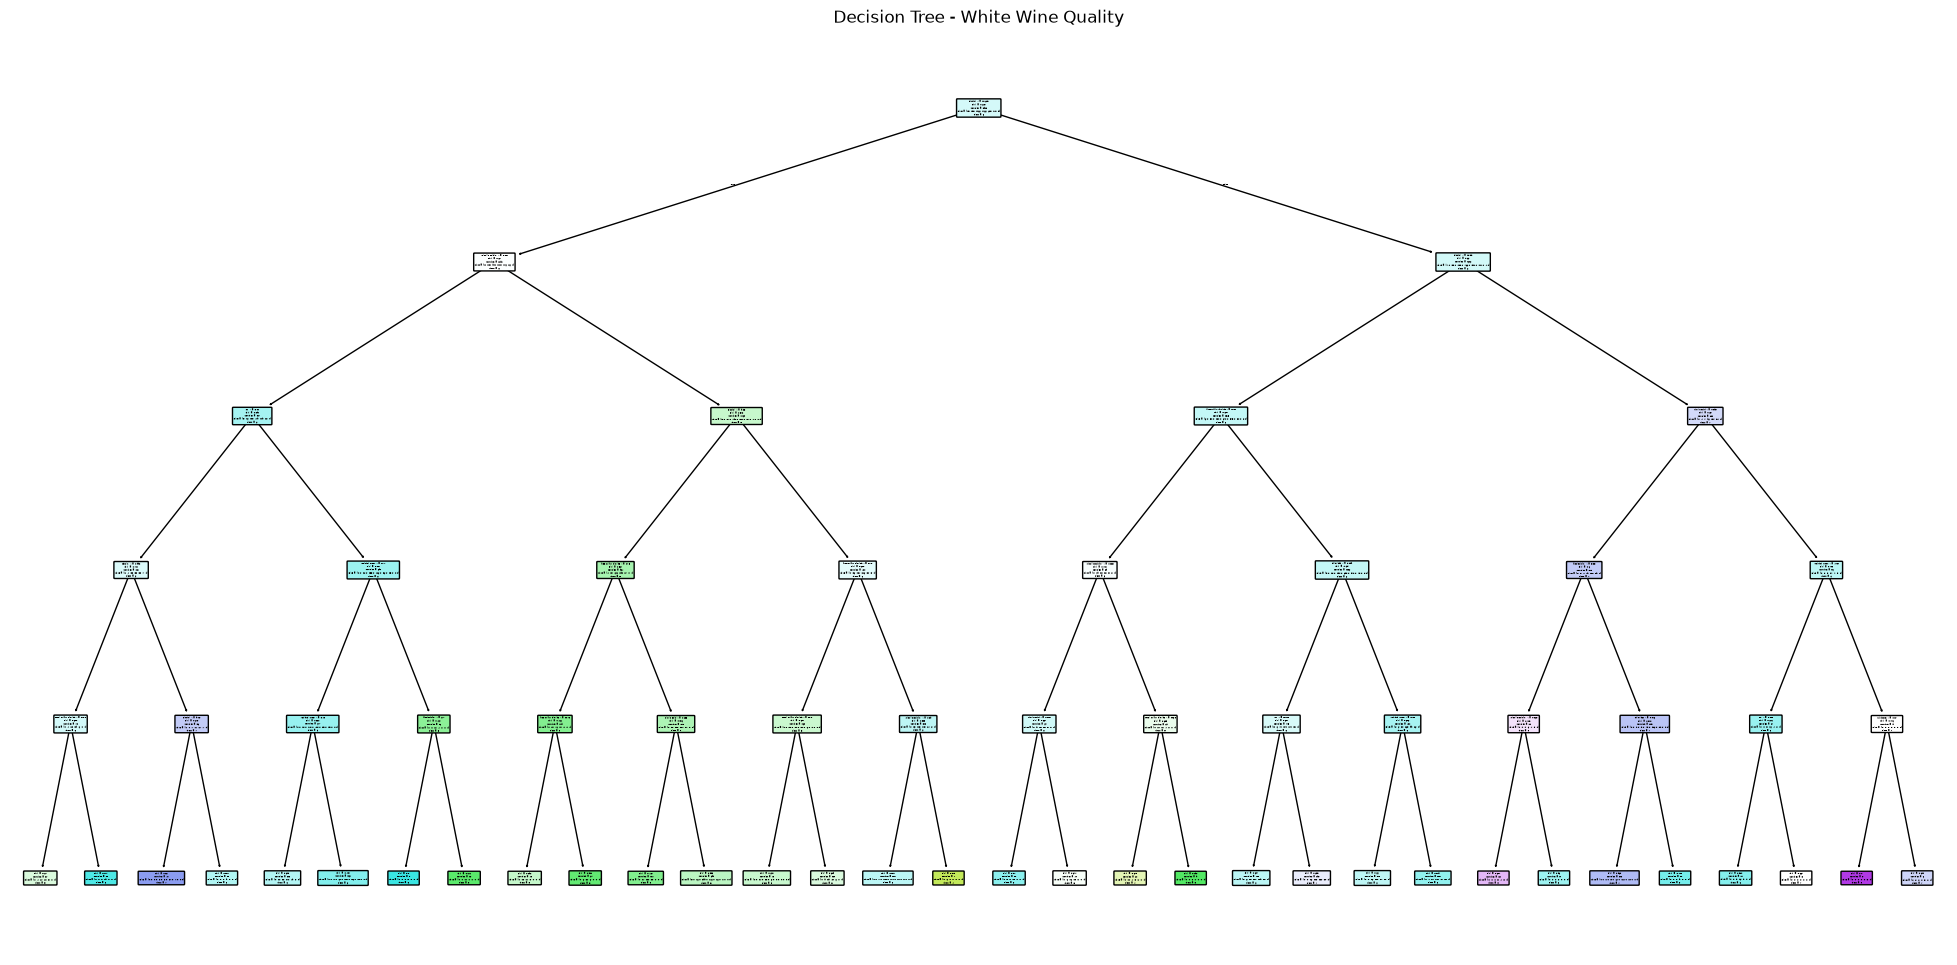

In [45]:
plt.figure(figsize=(25, 12))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=[
        str(x)
        for x in sorted(y.unique())
    ],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - White Wine Quality")

plt.show()

In [46]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
10               alcohol    0.466610
1       volatile acidity    0.219047
5    free sulfur dioxide    0.082227
3         residual sugar    0.044302
8                     pH    0.043612
6   total sulfur dioxide    0.036239
4              chlorides    0.031650
2            citric acid    0.029840
7                density    0.022078
0          fixed acidity    0.018119
9              sulphates    0.006277


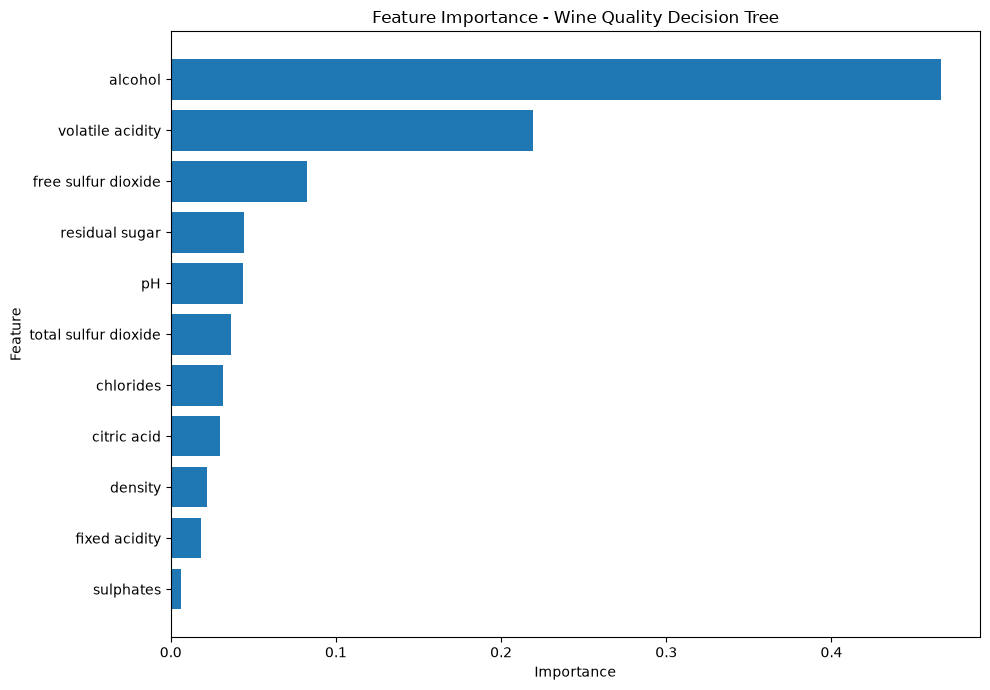

In [47]:
plt.figure(figsize=(10, 7))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title(
    "Feature Importance - Wine Quality Decision Tree"
)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

[[  0   0   1   4   0   0]
 [  0   2  15   8   0   0]
 [  0   1 170 111   8   1]
 [  0   3 113 269  47   0]
 [  0   0   6 114  64   8]
 [  0   0   1  15  18   1]]


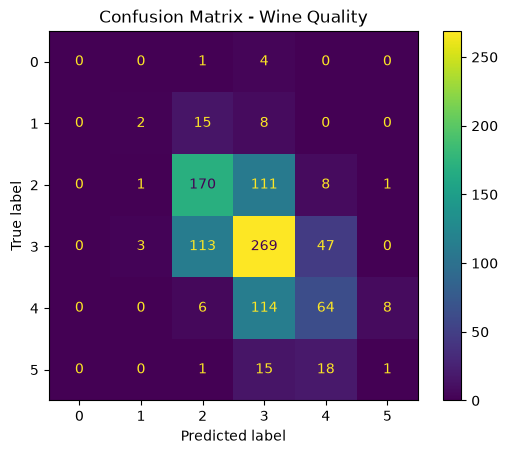

In [49]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title(
    "Confusion Matrix - Wine Quality"
)

plt.show()

In [53]:
depths = range(1, 16)

train_accuracy = []
test_accuracy = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(
        x_train,
        y_train
    )

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    train_accuracy.append(
        accuracy_score(
            y_train,
            train_pred
        )
    )

    test_accuracy.append(
        accuracy_score(
            y_test,
            test_pred
        )
    )

    print(train_accuracy)
    print(test_accuracy)

[0.4507401735579377]
[0.44081632653061226]
[0.4507401735579377, 0.5298621745788668]
[0.44081632653061226, 0.4969387755102041]
[0.4507401735579377, 0.5298621745788668, 0.5431342521694742]
[0.44081632653061226, 0.4969387755102041, 0.5091836734693878]
[0.4507401735579377, 0.5298621745788668, 0.5431342521694742, 0.5594691168963757]
[0.44081632653061226, 0.4969387755102041, 0.5091836734693878, 0.5102040816326531]
[0.4507401735579377, 0.5298621745788668, 0.5431342521694742, 0.5594691168963757, 0.5758039816232772]
[0.44081632653061226, 0.4969387755102041, 0.5091836734693878, 0.5102040816326531, 0.5163265306122449]
[0.4507401735579377, 0.5298621745788668, 0.5431342521694742, 0.5594691168963757, 0.5758039816232772, 0.5990301174068402]
[0.44081632653061226, 0.4969387755102041, 0.5091836734693878, 0.5102040816326531, 0.5163265306122449, 0.5142857142857142]
[0.4507401735579377, 0.5298621745788668, 0.5431342521694742, 0.5594691168963757, 0.5758039816232772, 0.5990301174068402, 0.6217457886676876]
[

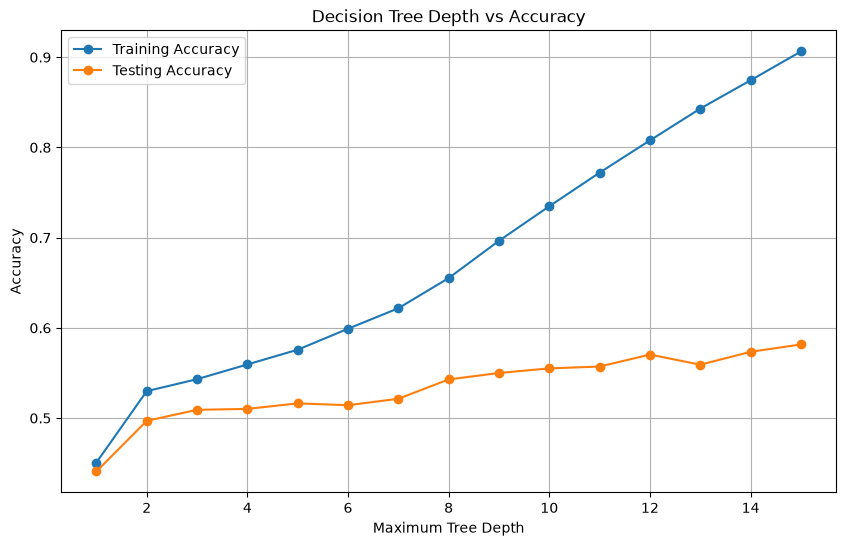

In [54]:
plt.figure(figsize=(10, 6))

plt.plot(
    depths,
    train_accuracy,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    test_accuracy,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")

plt.title(
    "Decision Tree Depth vs Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

In [55]:
gini_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    random_state=42
)

gini_model.fit(x_train, y_train)
entropy_model.fit(x_train, y_train)

gini_pred = gini_model.predict(x_test)
entropy_pred = entropy_model.predict(x_test)

print(
    "Gini Accuracy:",
    accuracy_score(y_test, gini_pred)
)

print(
    "Entropy Accuracy:",
    accuracy_score(y_test, entropy_pred)
)

Gini Accuracy: 0.5163265306122449
Entropy Accuracy: 0.523469387755102


In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       1.00      0.03      0.06        33
           5       0.52      0.62      0.57       291
           6       0.52      0.66      0.58       440
           7       0.42      0.18      0.25       176
           8       0.00      0.00      0.00        35
           9       0.00      0.00      0.00         1

    accuracy                           0.51       980
   macro avg       0.35      0.21      0.21       980
weighted avg       0.50      0.51      0.47       980



C:\Users\INDIA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\INDIA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\INDIA\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas